# DG-Hetero-GNN: Portable Paper Reproduction and Reviewer Walkthrough

This is the single review entry point. It is written for a reviewer who has no prior knowledge of this project and may have little machine-learning experience. It follows the attached paper as the normative specification and uses commit 9 only as the provenance of the processed graph archives.

### What problem is being solved?

The system detects fraudulent financial transactions. A transaction is not examined alone: it is connected to accounts, merchants, and other transactions, forming a **graph**. A graph contains **nodes** (things such as transactions) and **edges** (relationships such as an account making a transaction). A **heterogeneous graph** has several kinds of nodes and relationships.

The central challenge is **domain generalization**: a model trained on some datasets should still work on a different dataset whose patterns may be different. The proposed DG-Hetero-GNN combines a graph neural network with an adversarial domain classifier. In plain language, it learns information useful for fraud detection while being discouraged from memorizing which dataset a transaction came from.

### How to use this notebook

Run the cells from top to bottom. Most cells inspect the included completed experiment, so review does not require retraining. The deliberately guarded execution cell is the only cell that starts training. Each section states what it checks and how to interpret the output.

**Review checklist**

1. Verify archive hashes and Table 1 graph counts.
2. Inspect the leakage-safe LODO, OOD, and adaptive-OOD protocol.
3. Inspect the heterogeneous architecture, GRL, focal loss, baselines, and ablations.
4. Run deterministic validation tests.
5. Inspect or regenerate Tables 1–5 and Figures 2–3 from saved predictions.
6. Optionally launch a new smoke or complete five-seed run with visible progress.

The included `paper.pdf`, datasets, manifests, predictions, checkpoints, tables, and figures make this package portable after installing the pinned Python dependencies.

## 1. Setup, paths, and execution mode

**Purpose.** Establish where the package is located and prevent accidental retraining.

The code imports general-purpose libraries for paths, tables, arrays, subprocesses, and notebook display. `ROOT` is the extracted package directory. The package is considered portable only if `recovery-source/Datasets` exists below that directory. `COMPLETED_RUN` points to the included 40-epoch, five-seed results.

`EXECUTE_NEW_RUN` is intentionally `False`. This means running the notebook normally reads and explains existing evidence. A reviewer must consciously change it to `True` to spend time and GPU resources on a new experiment.

**Expected output.** All three presence checks should be `True`, and the printed root should be the extracted package folder.

In [ ]:
from pathlib import Path
import json, os, platform, subprocess, sys

required_python = '3.13.13'
active_python = platform.python_version()
if active_python != required_python:
    raise RuntimeError(f'Requires Python {required_python}; active kernel is Python {active_python}. Select the Python 3.13.13 kernel and restart.')

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'recovery-source' / 'Datasets').exists():
    raise FileNotFoundError('Run this notebook from the portable package root.')
PAPER = ROOT / 'paper.pdf'
COMPLETED_RUN = ROOT / 'artifacts_runs' / 'minimal-diff-notebook' / 'FULL_PAPER_RUN' / 'paper-full-20260830'
EXECUTE_NEW_RUN = False
NEW_RUN_MODE = 'SMOKE_TEST'  # Change to FULL_PAPER_RUN deliberately.
NEW_RUN_ID = 'notebook-review-run'
print('Package root:', ROOT)
print('Python:', active_python)
print('Paper present:', PAPER.exists())
print('Completed artifact run present:', COMPLETED_RUN.exists())

Package root: D:\Rayan Paper materials\DG_Hetero_GNN_Review_Package
Python: 3.13.13
Paper present: True
Completed artifact run present: True


## 2. Paper-controlled experimental protocol

**Key terms.** A **source domain** is a dataset whose labels may be used for training. A **target domain** is held out to simulate deployment on unfamiliar data. A **label** is the known answer: fraud or non-fraud. **LODO** means “leave one domain out.” **OOD** means “out of distribution,” or data unlike the training data.

The code imports the reviewed implementation and constructs a table describing exactly which datasets are sources and which dataset is the target. This is important because randomly mixing every dataset would leak knowledge of the target into training and would not test domain generalization.

For ordinary LODO and OOD, neither target features nor target labels enter training. Adaptive OOD is the one exception for features: it may inspect the structure and features of unlabeled AMLSim transactions, but it still cannot see their fraud labels. Labels are opened only after training to calculate final metrics.

**Expected output.** Every row must say `False` under target labels during training. Only Adaptive OOD should say `True` for target features.

In [2]:
from paper_reproduction_core import (
    ARCHIVES, HASHES, LODO, TABLE_1, Config, DGHeteroGNN, HeteroGraphSAGE,
    load_all, project_root, render_outputs, run_suite, select_threshold
)
scenario_rows = [
    {'Scenario': name, 'Sources': ', '.join(sources), 'Target': target,
     'Target features during training': False, 'Target labels during training': False}
    for name, (sources, target) in LODO.items()
]
scenario_rows += [
    {'Scenario':'OOD','Sources':'elliptic, ieee, dgraphfin','Target':'amlsim','Target features during training':False,'Target labels during training':False},
    {'Scenario':'Adaptive OOD','Sources':'elliptic, ieee, dgraphfin','Target':'amlsim','Target features during training':True,'Target labels during training':False},
]
display(pd.DataFrame(scenario_rows))

C:\Users\joel0\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Scenario,Sources,Target,Target features during training,Target labels during training
0,LODO0,"ieee, dgraphfin",elliptic,False,False
1,LODO1,"elliptic, dgraphfin",ieee,False,False
2,LODO2,"elliptic, ieee",dgraphfin,False,False
3,OOD,"elliptic, ieee, dgraphfin",amlsim,False,False
4,Adaptive OOD,"elliptic, ieee, dgraphfin",amlsim,True,False


## 3. Data integrity and reproduction of Paper Table 1

**Purpose.** Prove that the experiment uses the intended processed datasets and has not silently changed their graph structure.

A SHA-256 value is a digital fingerprint. If even one byte in an archive changes, its fingerprint changes. `load_all` verifies each archive against the expected fingerprint before loading it. It then checks that features contain finite numbers, transaction labels are binary, edge endpoints refer to real nodes, and the relation names exactly match the archived schema.

The paper requires 128 transaction features and 64 entity features. Some archived entity matrices contain 32 real columns, so the loader appends 32 zero columns; it does not invent information. Each archived directed relationship is counted once. No automatic reverse edges are added because the archives already contain meaningful forward and reverse relation types.

The final assertion compares transaction count, combined account/merchant count, feature size, and edge count with Paper Table 1.

**Expected output.** Four dataset rows followed by a `PASS` message. A hash, shape, schema, or count discrepancy stops execution rather than being ignored.

In [3]:
graphs, table1 = load_all(ROOT)
hash_table = pd.DataFrame([{'Dataset':name,'Archive':ARCHIVES[name],'Expected SHA-256':HASHES[name]} for name in ARCHIVES])
display(hash_table)
display(table1)
assert all(tuple(row) == TABLE_1[name] for name, row in zip(table1['Dataset'], table1[['Transaction nodes','Entity nodes','Feature size','Total edges']].itertuples(index=False,name=None)))
print('PASS: archive hashes, relation schema, finite features, binary labels, and Table 1 counts.')

,Dataset,Archive,Expected SHA-256
0,elliptic,elliptic_standardized.zip,0a86c749a1c388be50ca2a828485532216dd1cf29f39e9...
1,ieee,ieee_standardized.zip,e73460dffa01a807cdf113a768c535f8d21d9bf6a94e04...
2,dgraphfin,dgraphfin_reduced.zip,c7726f1dfd085e548ac86ad1cae62d751c87df95248260...
3,amlsim,amlsim_final_unified.zip,99dd1eb32ad2a71fd6eb95eaa942951599f88418c1fafe...


,Dataset,Transaction nodes,Entity nodes,Feature size,Total edges
0,elliptic,46564,93128,128,222880
1,ieee,590540,14962,128,2952700
2,dgraphfin,250000,324822,128,1036164
3,amlsim,45,35,128,443


PASS: archive hashes, relation schema, finite features, binary labels, and Table 1 counts.


## 4. Model architecture and information flow

### Plain-language overview

1. Each transaction, account, and merchant begins as a row of numbers called **features**.
2. Type-specific projection layers translate differently sized feature rows into a common 48-number representation.
3. Three GraphSAGE layers let connected nodes exchange summarized information. A transaction can therefore use context from its account, merchant, and neighboring transactions.
4. The fraud classifier converts the learned transaction representation into one score. A sigmoid later converts that score into a probability between 0 and 1.
5. During domain-generalized training, a second classifier tries to identify the source dataset. A **gradient reversal layer (GRL)** reverses its learning signal before it reaches the shared representation. Consequently, the domain classifier improves at its own task while the shared encoder learns to make dataset identity difficult to recover.

**Focal loss** reduces the influence of easy examples and focuses training on difficult cases, which is useful when fraud is rare. The independent HeteroGraphSAGE baseline has graph layers and a fraud head but deliberately has no GRL or domain classifier.

The code instantiates both models, counts their trainable parameters, and prints the proposed architecture. It does not train them in this cell.

**Expected output.** The proposed row should report a domain head and GRL; the baseline row should report neither.

In [4]:
cfg = Config(run_mode='SMOKE_TEST')
model = DGHeteroGNN(graphs['amlsim'].metadata(), cfg, n_domains=3)
baseline = HeteroGraphSAGE(graphs['amlsim'].metadata(), cfg)
display(pd.DataFrame([
 {'Component':'Proposed DG-Hetero-GNN','Parameters':sum(p.numel() for p in model.parameters()),'Domain head':True,'GRL':True},
 {'Component':'Independent HeteroGraphSAGE','Parameters':sum(p.numel() for p in baseline.parameters()),'Domain head':False,'GRL':False},
]))
print(model)

,Component,Parameters,Domain head,GRL
0,Proposed DG-Hetero-GNN,88644,True,True
1,Independent HeteroGraphSAGE,82609,False,False


DGHeteroGNN(
  (encoder): ModuleDict(
    (transaction): Sequential(
      (0): Linear(in_features=128, out_features=48, bias=True)
      (1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Dropout(p=0.15, inplace=False)
    )
    (account): Sequential(
      (0): Linear(in_features=64, out_features=48, bias=True)
      (1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Dropout(p=0.15, inplace=False)
    )
    (merchant): Sequential(
      (0): Linear(in_features=64, out_features=48, bias=True)
      (1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Dropout(p=0.15, inplace=False)
    )
  )
  (layers): ModuleList(
    (0-2): 3 x HeteroConv(num_relations=5)
  )
  (classifier): Sequential(
    (0): Linear(in_features=48, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (

## 5. Automated validation gates

**Purpose.** Catch implementation errors before trusting any accuracy number.

This cell launches `reproduction_tests.py` as a separate Python process, similar to an independent reviewer running the tests from a terminal. The tests verify:

- archived edges are neither duplicated nor silently reversed;
- Paper Table 1 counts match exactly;
- gradient reversal changes the gradient sign as intended;
- the optimized threshold algorithm returns exactly the same answer as exhaustive search;
- creating a GPU view does not move or corrupt the retained CPU graph;
- the adaptive training function cannot read target labels;
- HeteroGraphSAGE is structurally independent of domain-adversarial machinery; and
- the implementation is embedded in the two audit notebooks rather than hidden behind a different import.

**Expected output.** A single `PASS` line and return code zero. Any failed assertion stops this notebook.

In [5]:
completed = subprocess.run([sys.executable, '-u', 'reproduction_tests.py'], cwd=ROOT, text=True, capture_output=True)
print(completed.stdout)
if completed.stderr: print(completed.stderr)
assert completed.returncode == 0

PASS: topology, Table 1, threshold equivalence, device isolation, leakage guard, baseline independence, and embedded notebooks



## 6. Optional one-time execution

**This is the training control cell.** With the default `EXECUTE_NEW_RUN=False`, it only prints the location of the included completed run.

If enabled, `run_suite` performs every scenario, model, random seed, and ablation. A **seed** fixes pseudo-random choices; repeating five seeds measures how sensitive results are to random initialization. An **epoch** is one complete optimization pass. Smoke mode uses one seed and two epochs solely to find wiring errors. Full mode uses the paper protocol of five seeds and 40 epochs.

Every finished seed writes an atomic checkpoint. If the process stops, rerunning with the same run ID skips verified completed seeds. Terminal messages identify scenario, model, seed, epoch, loss, elapsed time, and CUDA memory.

**Important interpretation.** A successful smoke run proves executability, not scientific performance. Only `FULL_PAPER_RUN` is eligible for comparison with the paper.

In [6]:
if EXECUTE_NEW_RUN:
    new_cfg = Config(run_mode=NEW_RUN_MODE)
    NEW_RESULTS = run_suite(ROOT, new_cfg, run_id=NEW_RUN_ID, implementation_id='portable-review-notebook')
else:
    print('Training skipped. Reviewing included completed run:', COMPLETED_RUN)

Training skipped. Reviewing included completed run: D:\Rayan Paper materials\DG_Hetero_GNN_Review_Package\artifacts_runs\minimal-diff-notebook\FULL_PAPER_RUN\paper-full-20260830


## 7. Audit the included completed run

The **manifest** is the run's identity card. It records the exact configuration, dataset fingerprints, Python/library versions, GPU/CUDA information, run ID, timestamps, and final status. This prevents results from a smoke test or another configuration being mistaken for the full experiment.

The inventory counts evidence files. There are 35 scenario/model combinations and five seeds each, producing 175 per-seed result files and 175 prediction archives. PyTorch models have `.pt` checkpoints; XGBoost accounts for the combinations without `.pt` files. Aggregate JSON files contain means and standard deviations across seeds.

**Expected output.** Status `complete`, 35 aggregates, 175 seed results, 175 predictions, eight tables, and nine figures. The assertions stop execution if the essential counts differ.

In [7]:
manifest = json.loads((COMPLETED_RUN/'manifest.json').read_text(encoding='utf-8'))
inventory = {
 'Manifest status':manifest['status'],
 'Aggregate result JSON':len([p for p in (COMPLETED_RUN/'results').glob('*.json') if '_seed' not in p.stem]),
 'Per-seed result JSON':len(list((COMPLETED_RUN/'results').glob('*_seed*.json'))),
 'Prediction archives':len(list((COMPLETED_RUN/'predictions').glob('*.npz'))),
 'Model checkpoints':len(list((COMPLETED_RUN/'models').glob('*.pt'))),
 'CSV tables':len(list((COMPLETED_RUN/'tables').glob('*.csv'))),
 'PNG figures':len(list((COMPLETED_RUN/'figures').glob('*.png'))),
}
display(pd.Series(inventory, name='Value').to_frame())
assert manifest['status']=='complete' and inventory['Per-seed result JSON']==175 and inventory['Prediction archives']==175

,Value
Manifest status,complete
Aggregate result JSON,35
Per-seed result JSON,175
Prediction archives,175
Model checkpoints,155
CSV tables,8
PNG figures,9


## 8. Computed Tables 1–5

This cell reads CSV files produced by the completed run and displays them without alteration.

- **Table 1** describes graph sizes and validates the data foundation.
- **Table 2** compares all models in the three leave-one-domain-out scenarios.
- **Table 3** isolates the proposed DG-Hetero-GNN LODO results.
- **Table 4** compares models when AMLSim is the unseen OOD target.
- **Table 5** compares ordinary OOD with adaptive OOD.

Common metrics: **ROC-AUC** and **PR-AUC** judge probability ranking across thresholds; **precision** asks how many predicted frauds were truly fraud; **recall** asks how many real frauds were found; **F1** balances precision and recall. `mean` averages five seeds and `std` shows their variation.

All displayed values are computed artifacts. Paper-reported numbers are never inserted in place of reproduced values.

In [8]:
table_files = ['table1_graph_statistics.csv','table2_lodo_all_models.csv','table3_lodo_dg_hetero_gnn.csv','table4_ood_amlsim.csv','table5_ood_vs_adaptive.csv']
for filename in table_files:
    display(Markdown('### '+filename.replace('_',' ').replace('.csv','').title()))
    display(pd.read_csv(COMPLETED_RUN/'tables'/filename))

### Table1 Graph Statistics

,Dataset,Transaction nodes,Entity nodes,Feature size,Total edges
0,elliptic,46564,93128,128,222880
1,ieee,590540,14962,128,2952700
2,dgraphfin,250000,324822,128,1036164
3,amlsim,45,35,128,443


### Table2 Lodo All Models

,scenario,model,ROC-AUC_mean,PR-AUC_mean,Precision_mean,Recall_mean,F1_mean,selected_threshold_mean,ECE_mean,Brier_mean,...,Precision_std,Recall_std,F1_std,selected_threshold_std,ECE_std,Brier_std,TP_std,TN_std,FP_std,FN_std
0,LODO0,DG-Hetero-GNN,0.564044,0.121474,0.081774,0.548515,0.131092,0.076647,0.040322,0.088867,...,0.038909,0.430583,0.077569,0.045146,0.007771,0.001178,1957.001584,15689.555323,15689.555323,1957.001584
1,LODO0,GAT,0.611023,0.130949,0.119820,0.777074,0.202589,0.212014,0.182356,0.129480,...,0.018666,0.257176,0.033207,0.093678,0.062830,0.022711,1168.864475,9875.007172,9875.007172,1168.864475
2,LODO0,GCN,0.641704,0.134530,0.117485,0.376634,0.144409,0.275652,0.105954,0.103875,...,0.057052,0.362317,0.083434,0.157148,0.037889,0.007027,1646.730263,15221.176333,15221.176333,1646.730263
3,LODO0,GraphSAGE,0.631603,0.122139,0.089132,0.083256,0.084203,0.170139,0.074690,0.094084,...,0.035388,0.043598,0.038821,0.031150,0.008617,0.001487,198.154081,1226.675442,1226.675442,198.154081
4,LODO0,HeteroGraphSAGE,0.623797,0.126399,0.099526,0.285281,0.133497,0.247099,0.119665,0.101376,...,0.071829,0.335833,0.113502,0.014022,0.017416,0.004471,1526.359800,7157.862798,7157.862798,1526.359800
5,LODO0,MLP,0.636603,0.125252,0.125444,0.245061,0.160995,0.310765,0.099723,0.103083,...,0.014088,0.111415,0.029039,0.037796,0.037995,0.009228,506.381437,3136.942550,3136.942550,506.381437
6,LODO0,XGBoost,0.662079,0.145944,0.117121,0.974741,0.209086,0.164646,0.200710,0.140301,...,0.004101,0.007836,0.006508,0.016954,0.038356,0.014734,35.616850,1434.422616,1434.422616,35.616850
7,LODO1,DG-Hetero-GNN,0.561068,0.042925,0.058189,0.018855,0.009229,0.176418,0.063955,0.040615,...,0.102008,0.037565,0.018170,0.095885,0.049493,0.005573,776.203478,25051.100865,25051.100865,776.203478
8,LODO1,GAT,0.446337,0.037035,0.030772,0.811847,0.059282,0.162483,0.301612,0.132908,...,0.005550,0.203085,0.010844,0.051589,0.045163,0.025890,4196.343713,42898.488867,42898.488867,4196.343713
9,LODO1,GCN,0.379622,0.027422,0.034988,0.999806,0.067611,0.202236,0.390816,0.187840,...,0.000008,0.000387,0.000015,0.018247,0.021317,0.016941,8.000000,93.745187,93.745187,8.000000


### Table3 Lodo Dg Hetero Gnn

,scenario,model,ROC-AUC_mean,PR-AUC_mean,Precision_mean,Recall_mean,F1_mean,selected_threshold_mean,ECE_mean,Brier_mean,...,Precision_std,Recall_std,F1_std,selected_threshold_std,ECE_std,Brier_std,TP_std,TN_std,FP_std,FN_std
0,LODO0,DG-Hetero-GNN,0.564044,0.121474,0.081774,0.548515,0.131092,0.076647,0.040322,0.088867,...,0.038909,0.430583,0.077569,0.045146,0.007771,0.001178,1957.001584,15689.555323,15689.555323,1957.001584
1,LODO1,DG-Hetero-GNN,0.561068,0.042925,0.058189,0.018855,0.009229,0.176418,0.063955,0.040615,...,0.102008,0.037565,0.018170,0.095885,0.049493,0.005573,776.203478,25051.100865,25051.100865,776.203478
2,LODO2,DG-Hetero-GNN,0.541940,0.070659,0.068095,0.790651,0.115843,0.133985,0.130811,0.080629,...,0.011414,0.326460,0.002522,0.071216,0.066164,0.016133,5063.075800,80597.458708,80597.458708,5063.075800


### Table4 Ood Amlsim

,scenario,model,ROC-AUC_mean,PR-AUC_mean,Precision_mean,Recall_mean,F1_mean,selected_threshold_mean,ECE_mean,Brier_mean,...,Precision_std,Recall_std,F1_std,selected_threshold_std,ECE_std,Brier_std,TP_std,TN_std,FP_std,FN_std
0,OOD,DG-Hetero-GNN,0.4244,0.532718,0.420559,0.424,0.408517,0.052120,0.510423,0.510774,...,0.232133,0.307350,0.251408,0.035971,0.039591,0.037976,7.683749,5.932959,5.932959,7.683749
1,OOD,GAT,0.3440,0.502196,0.555556,1.000,0.714286,0.234862,0.126931,0.263755,...,0.000000,0.000000,0.000000,0.083438,0.025989,0.002741,0.000000,0.000000,0.000000,0.000000
2,OOD,GCN,0.5208,0.591279,0.555556,1.000,0.714286,0.214973,0.118450,0.258942,...,0.000000,0.000000,0.000000,0.096740,0.009828,0.003886,0.000000,0.000000,0.000000,0.000000
3,OOD,GraphSAGE,0.2832,0.471295,0.555556,1.000,0.714286,0.225053,0.162745,0.276185,...,0.000000,0.000000,0.000000,0.036591,0.033979,0.010490,0.000000,0.000000,0.000000,0.000000
4,OOD,HeteroGraphSAGE,0.5040,0.604619,0.316667,0.064,0.105895,0.241387,0.384517,0.391948,...,0.388730,0.082365,0.134756,0.016867,0.011439,0.008894,2.059126,0.489898,0.489898,2.059126
5,OOD,MLP,0.4016,0.538901,0.555556,1.000,0.714286,0.330315,0.094740,0.257704,...,0.000000,0.000000,0.000000,0.036732,0.029232,0.005827,0.000000,0.000000,0.000000,0.000000
6,OOD,XGBoost,0.5616,0.590656,0.000000,0.000,0.000000,0.187655,0.511867,0.506737,...,0.000000,0.000000,0.000000,0.011348,0.001691,0.001830,0.000000,0.000000,0.000000,0.000000


### Table5 Ood Vs Adaptive

,scenario,model,ROC-AUC_mean,PR-AUC_mean,Precision_mean,Recall_mean,F1_mean,selected_threshold_mean,ECE_mean,Brier_mean,...,Precision_std,Recall_std,F1_std,selected_threshold_std,ECE_std,Brier_std,TP_std,TN_std,FP_std,FN_std
0,ADAPTIVE_OOD,DG-Hetero-GNN,0.3068,0.457350,0.300483,0.472,0.360714,0.042259,0.509763,0.511478,...,0.252568,0.450706,0.319518,0.046838,0.049311,0.044851,11.267653,9.086253,9.086253,11.267653
1,OOD,DG-Hetero-GNN,0.4244,0.532718,0.420559,0.424,0.408517,0.052120,0.510423,0.510774,...,0.232133,0.307350,0.251408,0.035971,0.039591,0.037976,7.683749,5.932959,5.932959,7.683749


## 9. Figures 2(a–e): understanding OOD behavior

- A **precision–recall curve** shows the trade-off between finding more fraud and producing more false alarms. Curves nearer the upper-right are generally better.
- A **ROC curve** compares true-positive and false-positive rates. The diagonal represents random ranking.
- A **confusion matrix** counts true negatives, false positives, false negatives, and true positives. It exposes failure modes hidden by a single score.
- The OOD/adaptive comparison asks whether unlabeled target features improve transfer.
- **Calibration** asks whether predicted probabilities match observed frequencies. Lower ECE and Brier scores are better.

These figures are loaded from the completed run. Their underlying coordinates and metrics are also saved as CSV/NPZ evidence.

### figure2a_ood_pr.png

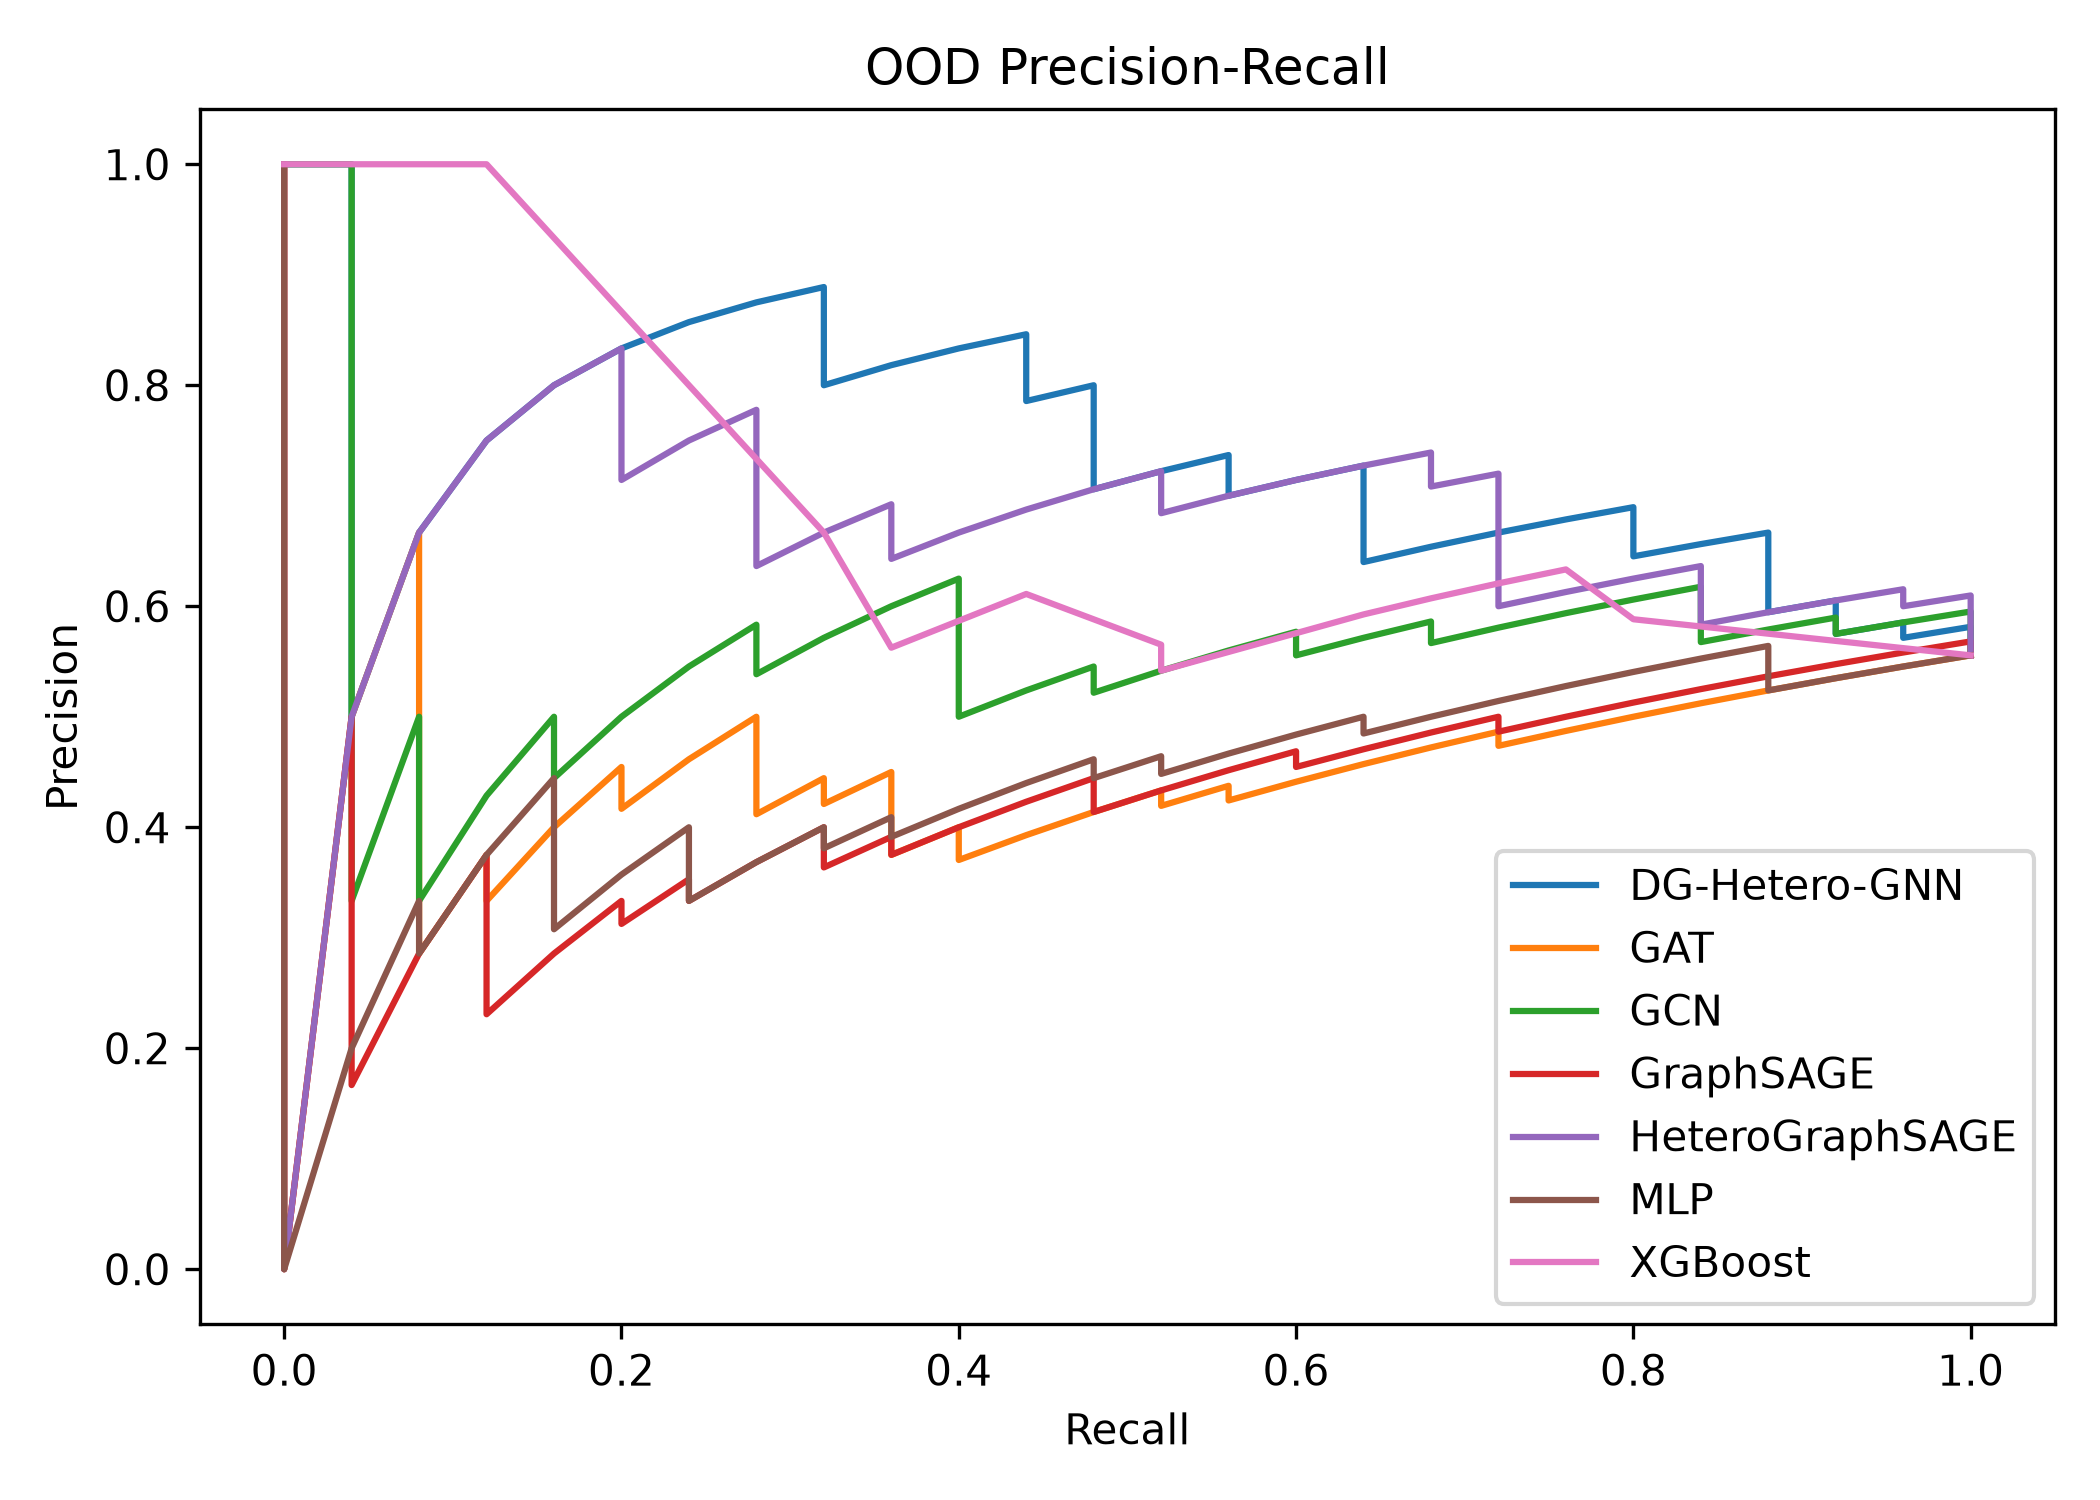

### figure2b_ood_roc.png

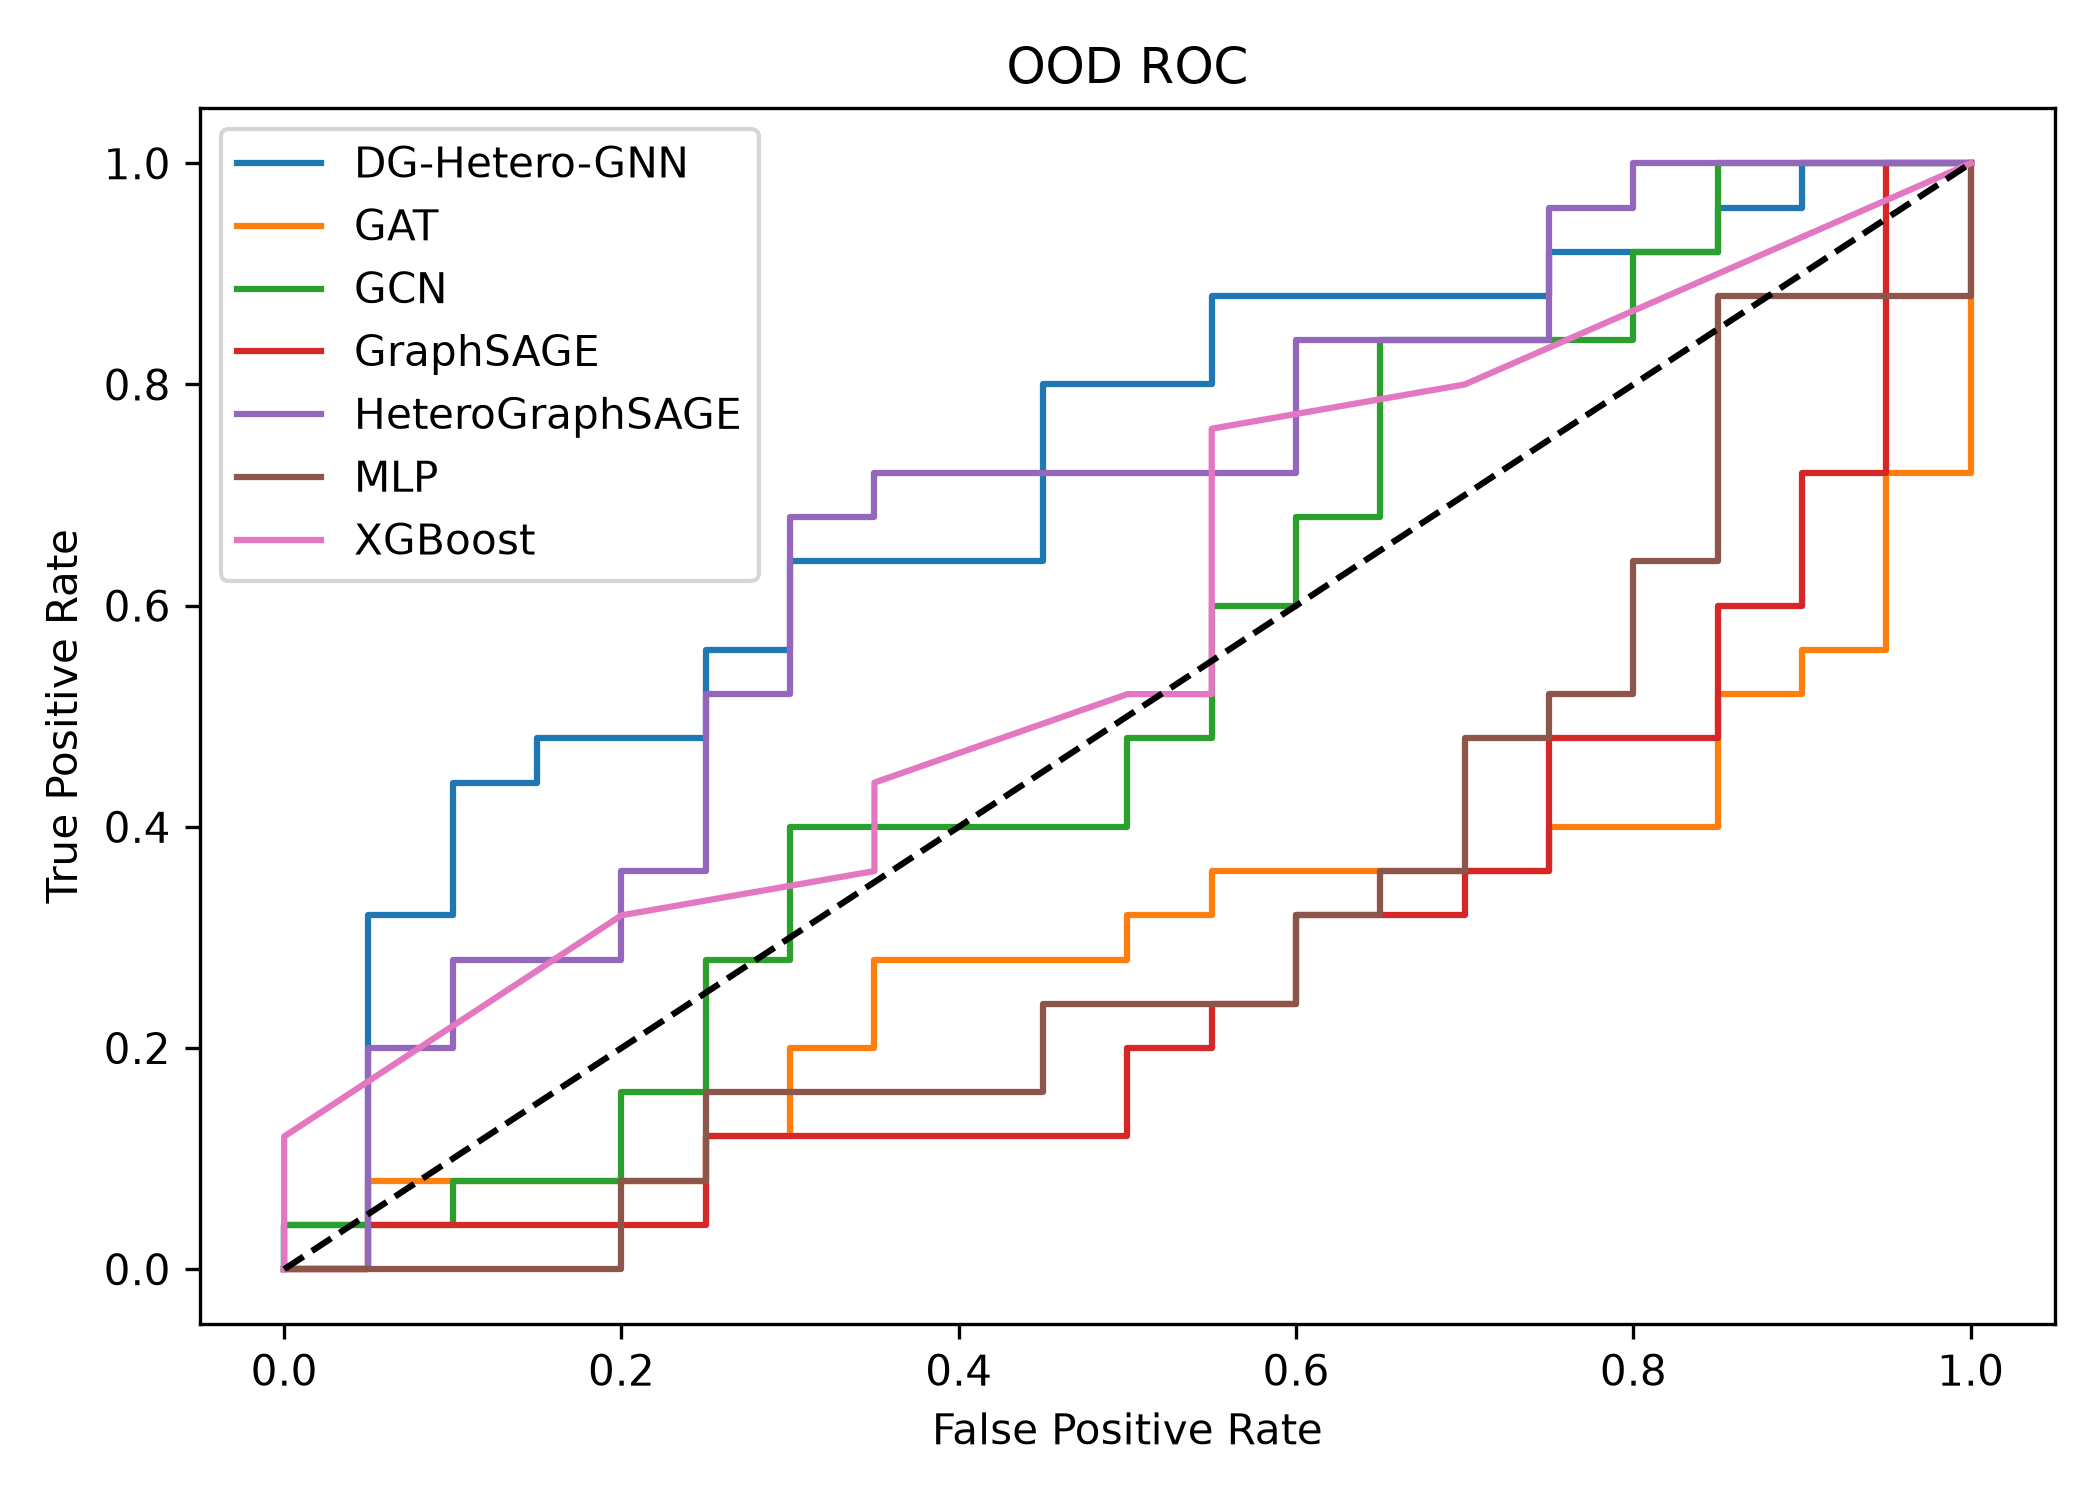

### figure2c_ood_confusion_heatmaps.png

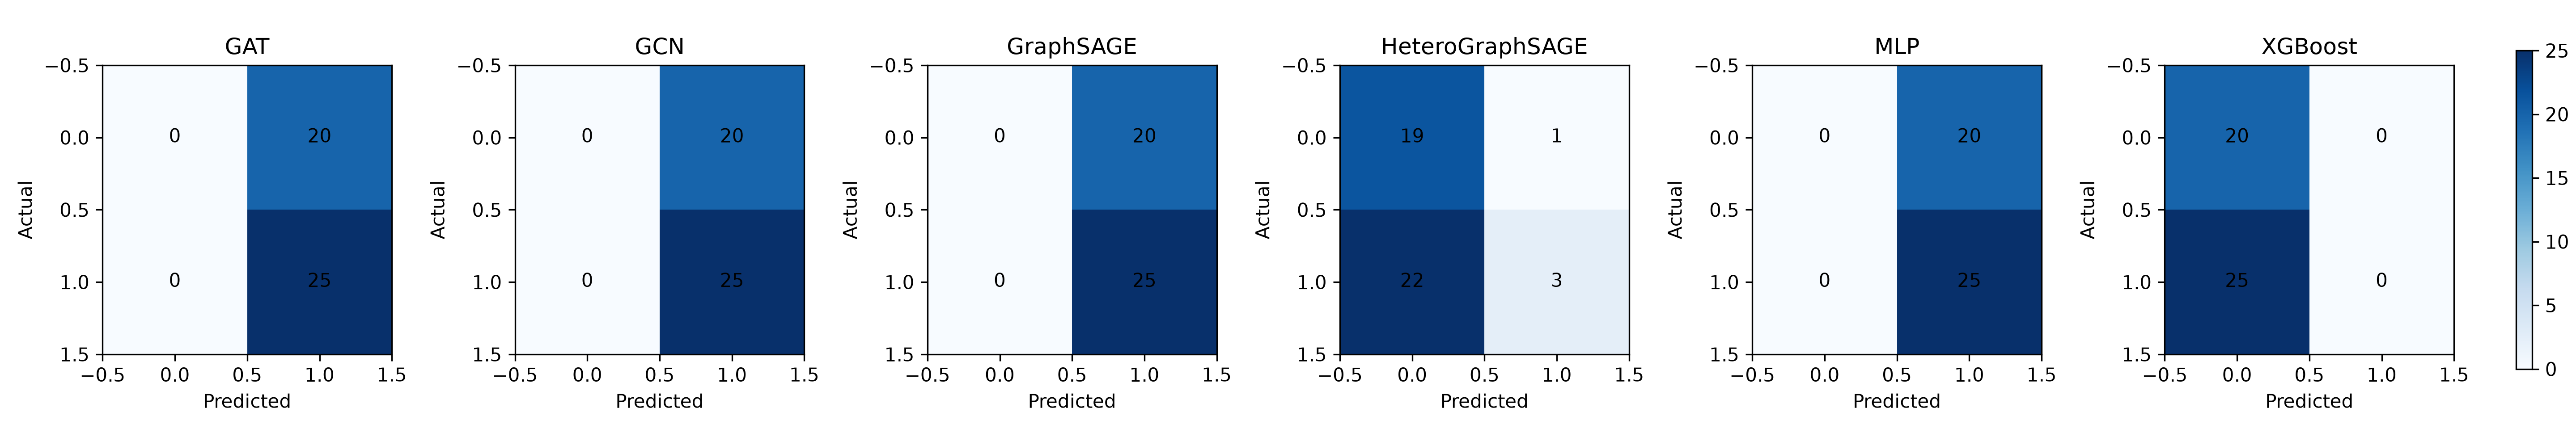

### figure2d_ood_vs_adaptive.png

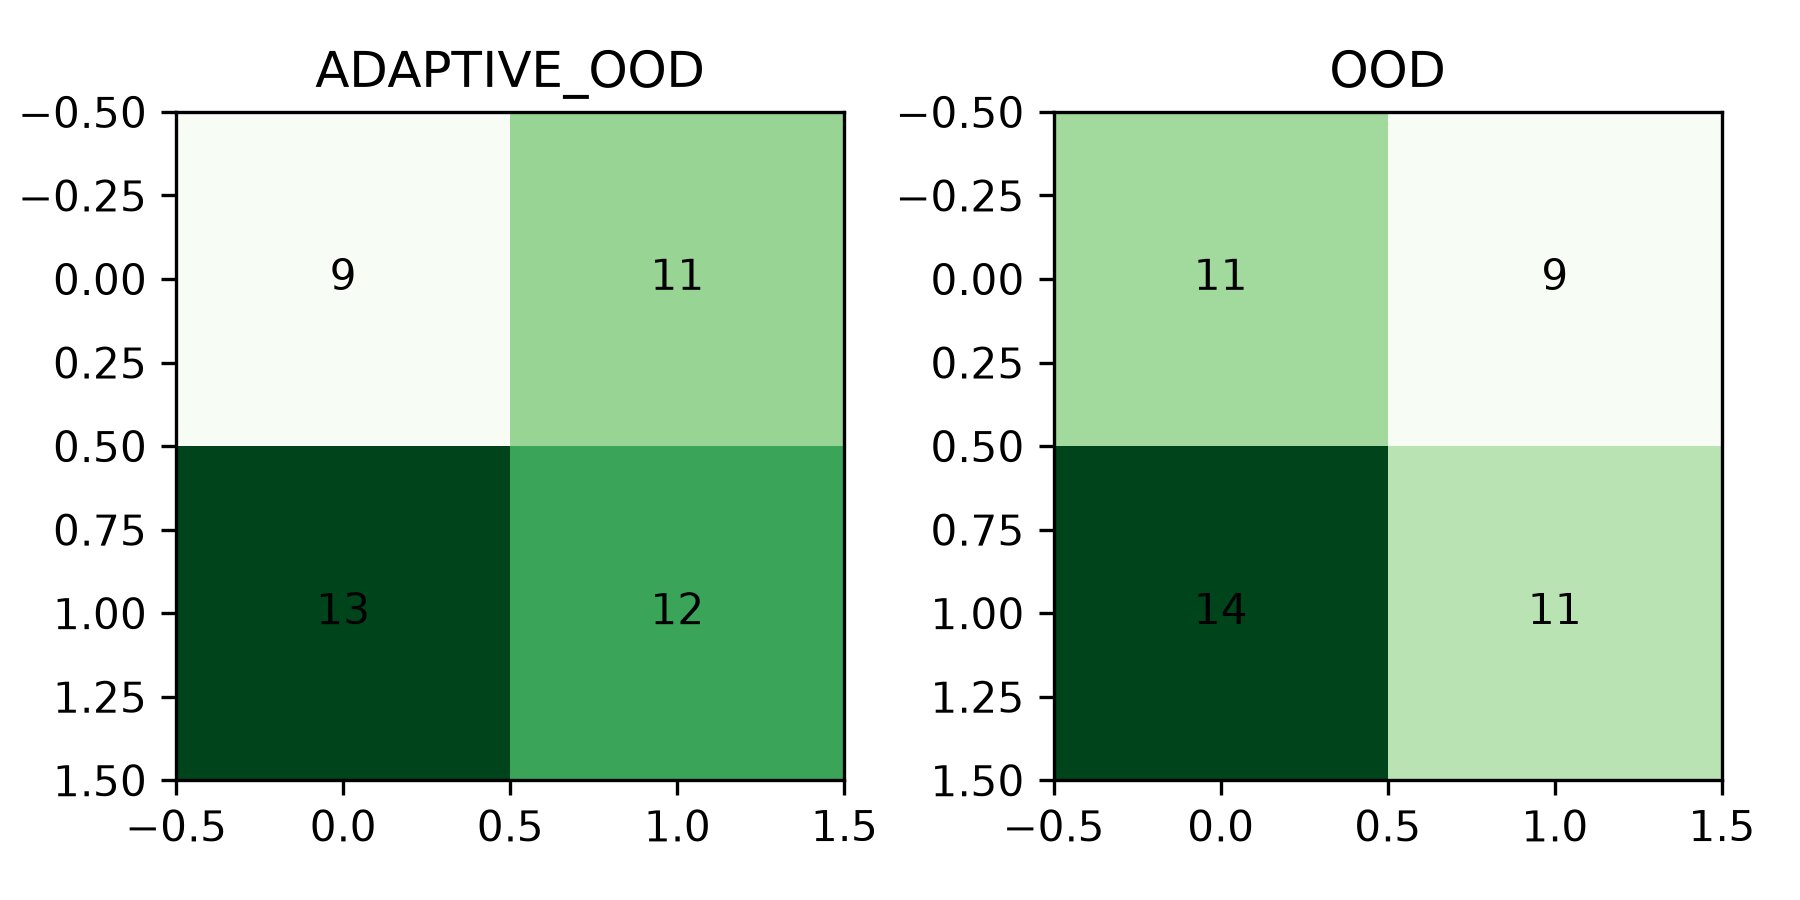

### figure2e_calibration.png

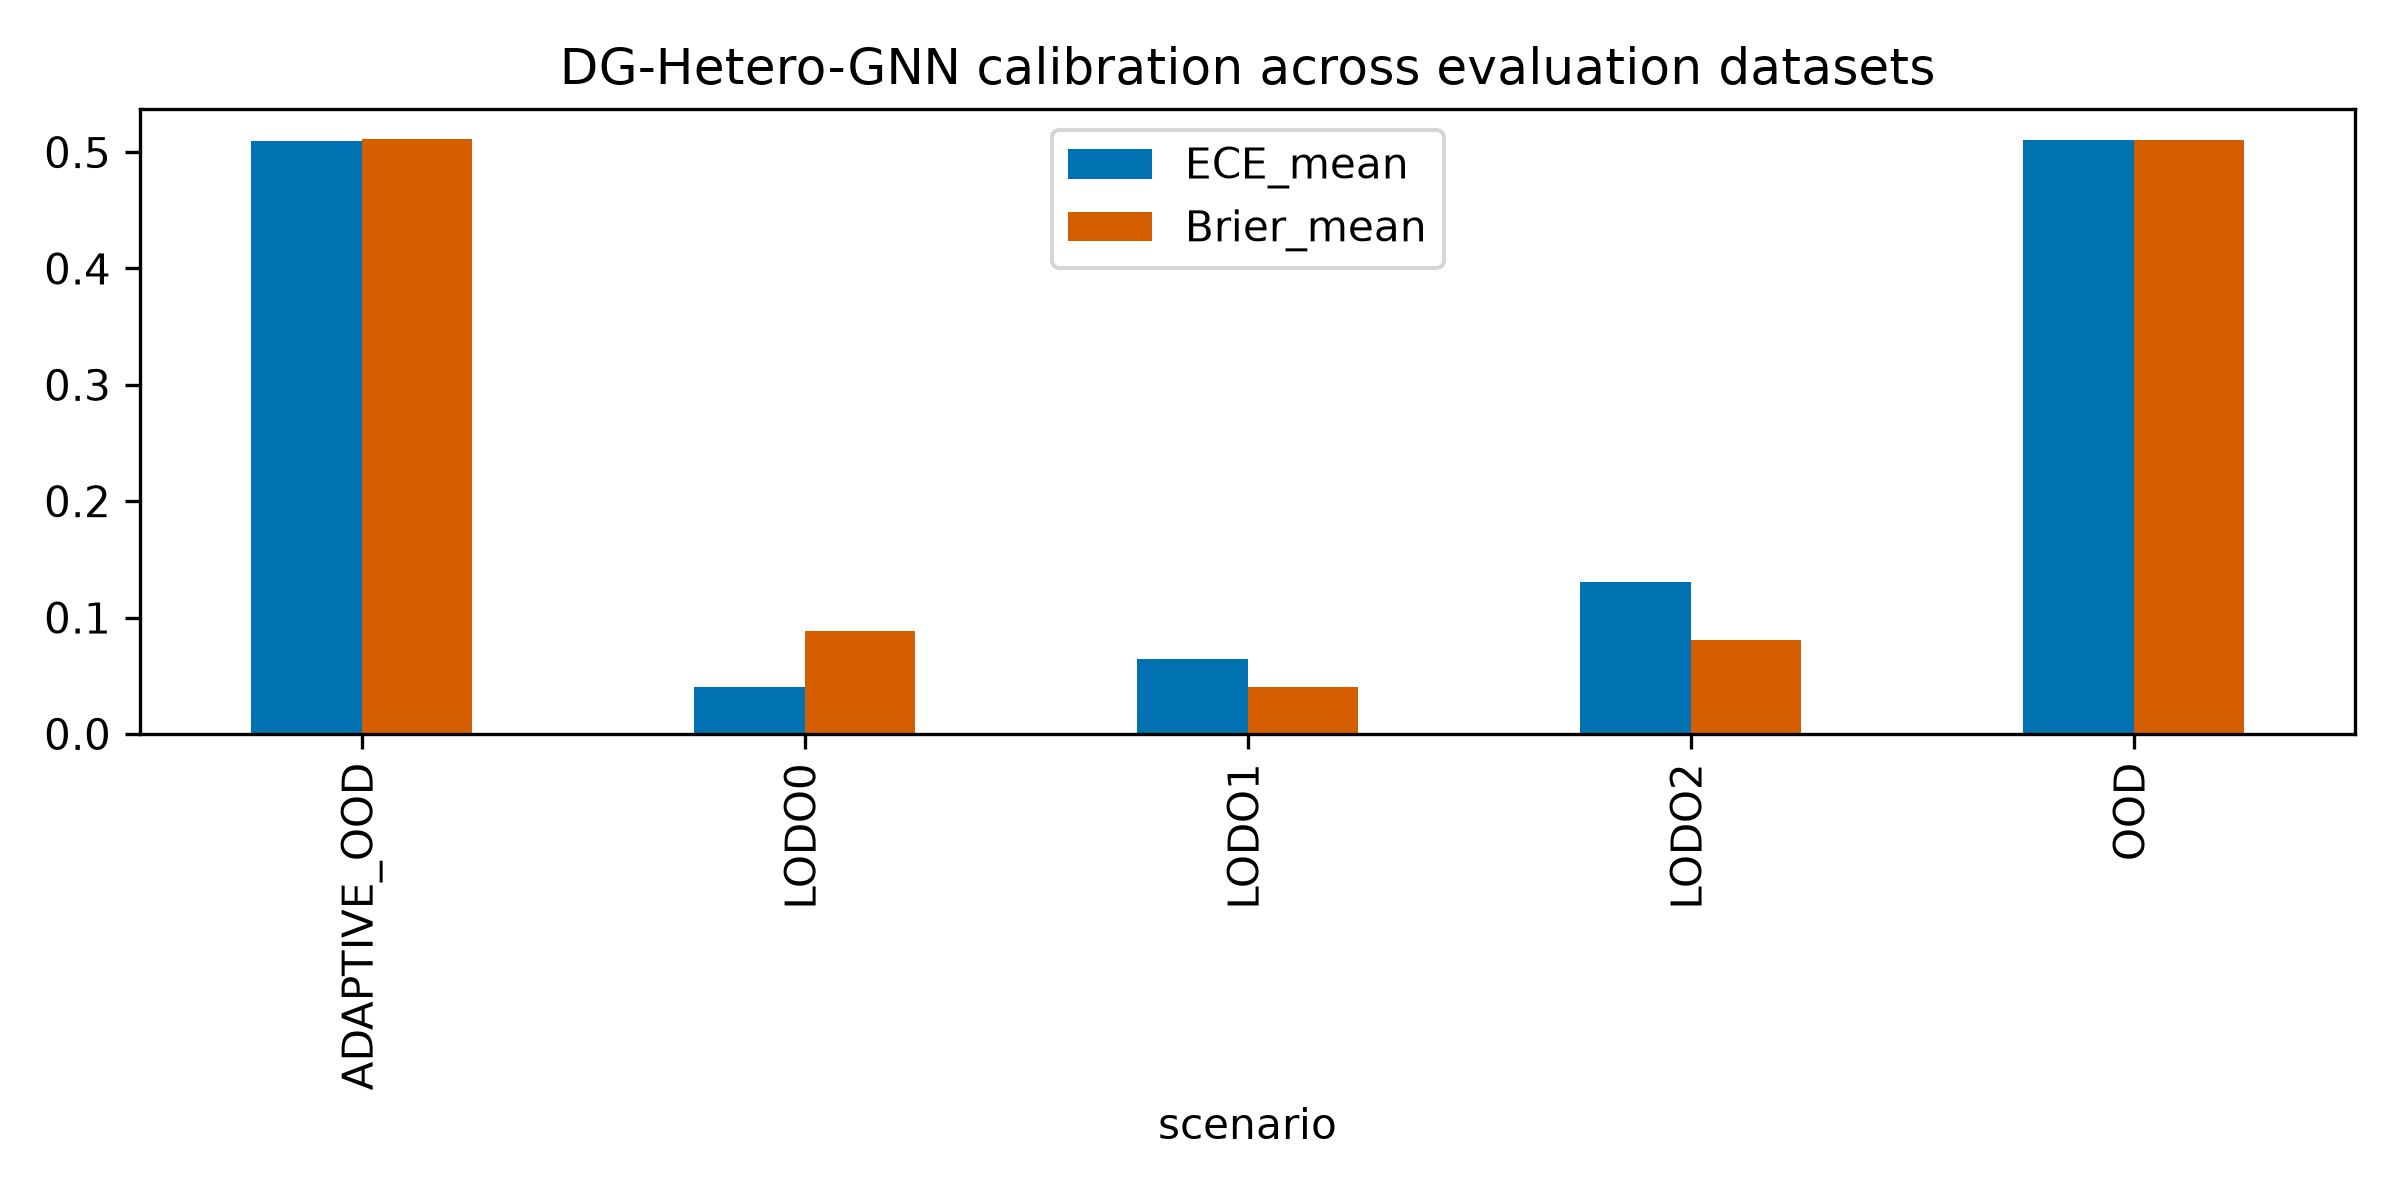

In [9]:
for filename in ['figure2a_ood_pr.png','figure2b_ood_roc.png','figure2c_ood_confusion_heatmaps.png','figure2d_ood_vs_adaptive.png','figure2e_calibration.png']:
    display(Markdown('### '+filename))
    display(Image(filename=str(COMPLETED_RUN/'figures'/filename), width=1000))

## 10. Figures 3(a–d): cross-domain comparison and ablations

The first three charts compare mean ROC-AUC, PR-AUC, and F1 when each major dataset is held out in turn. Performance may differ substantially by target because each dataset has different fraud patterns and class balance.

An **ablation** removes or changes one component to test whether that component matters. Examples include removing type-specific projection, heterogeneous message passing, domain generalization, the deep classifier, or learned threshold selection. An ablation is not a new proposed model; it is a controlled diagnostic.

### figure3a_lodo_roc_auc.png

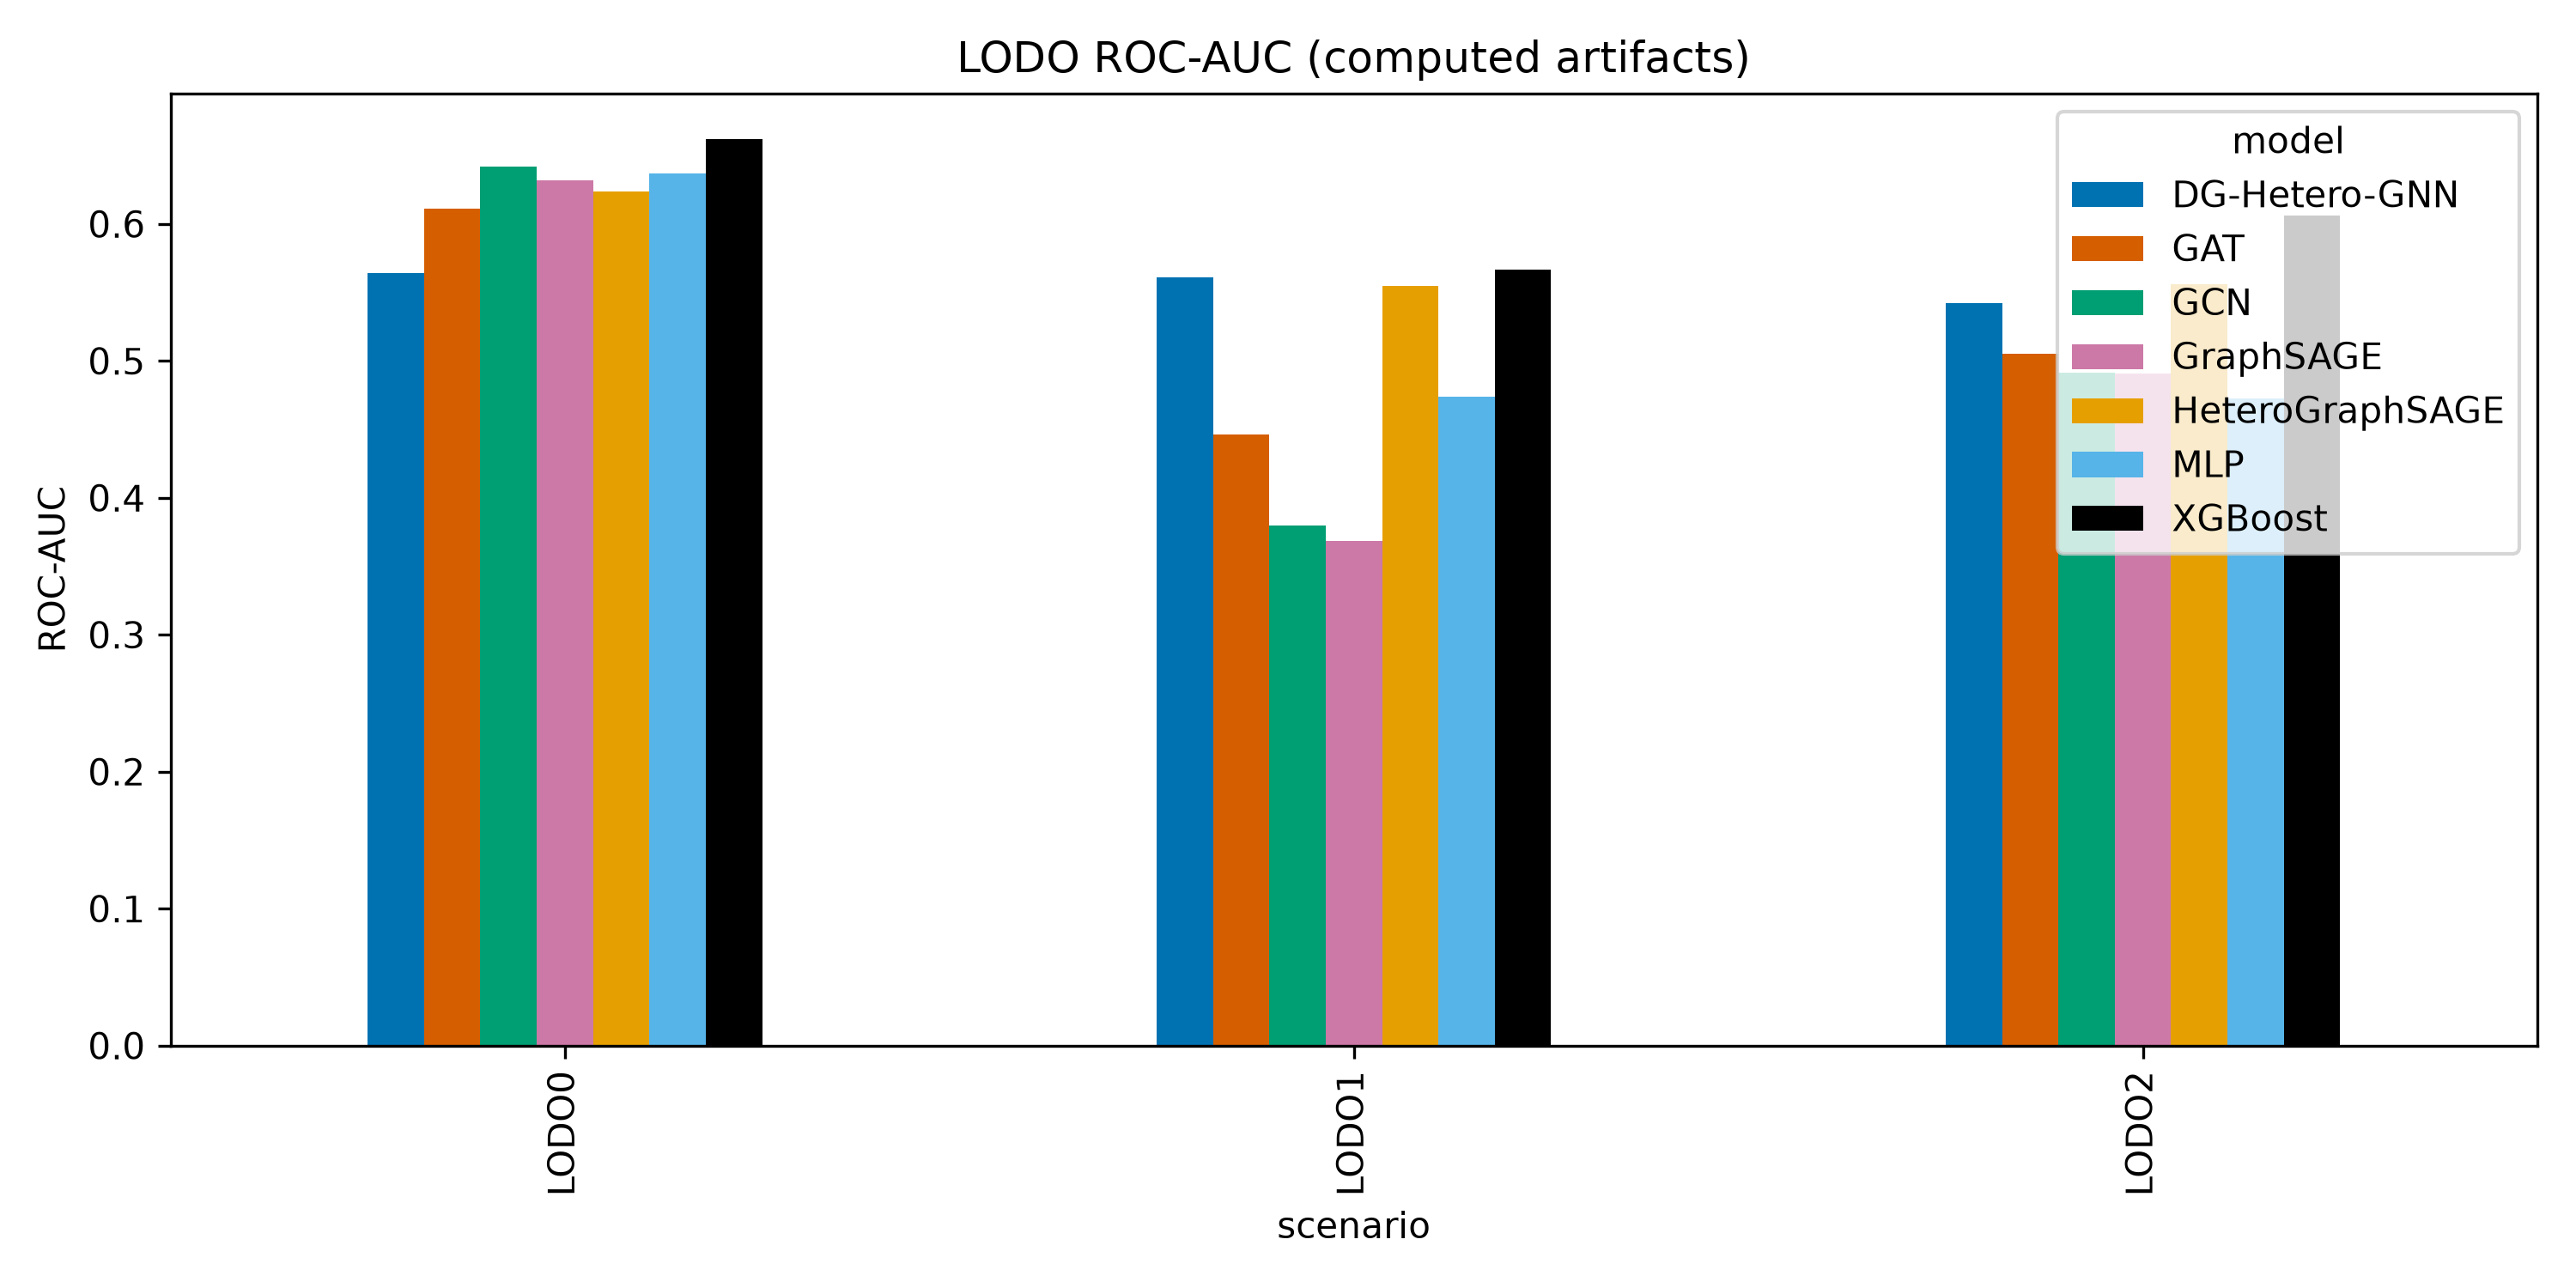

### figure3b_lodo_pr_auc.png

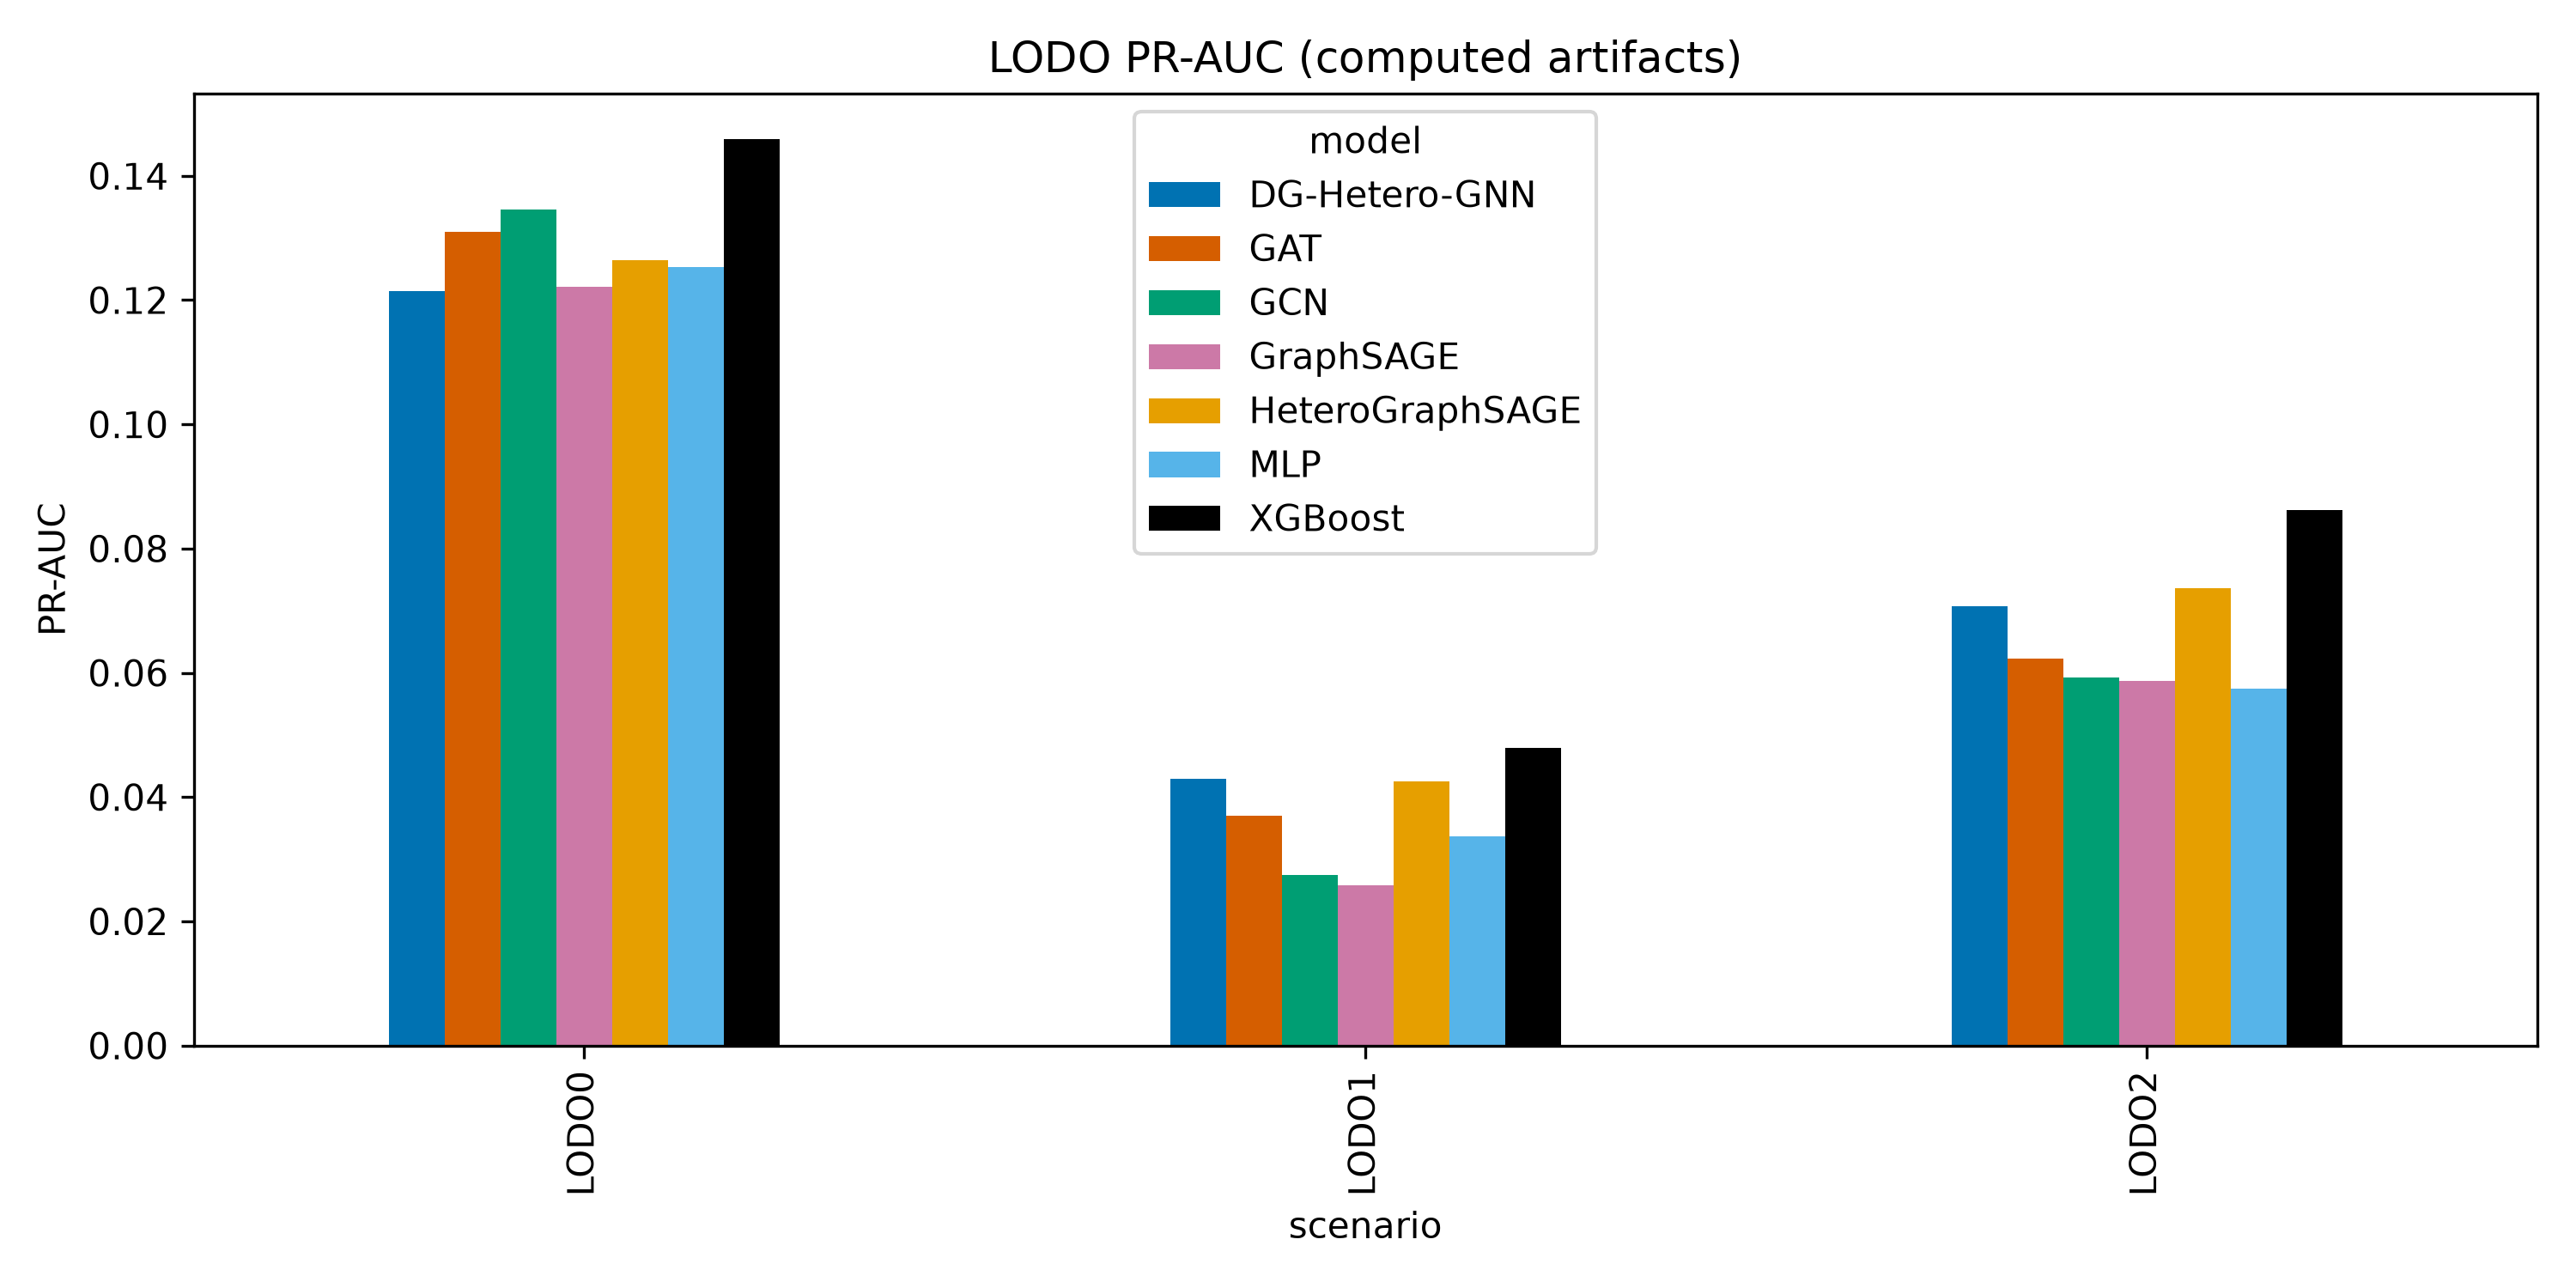

### figure3c_lodo_f1.png

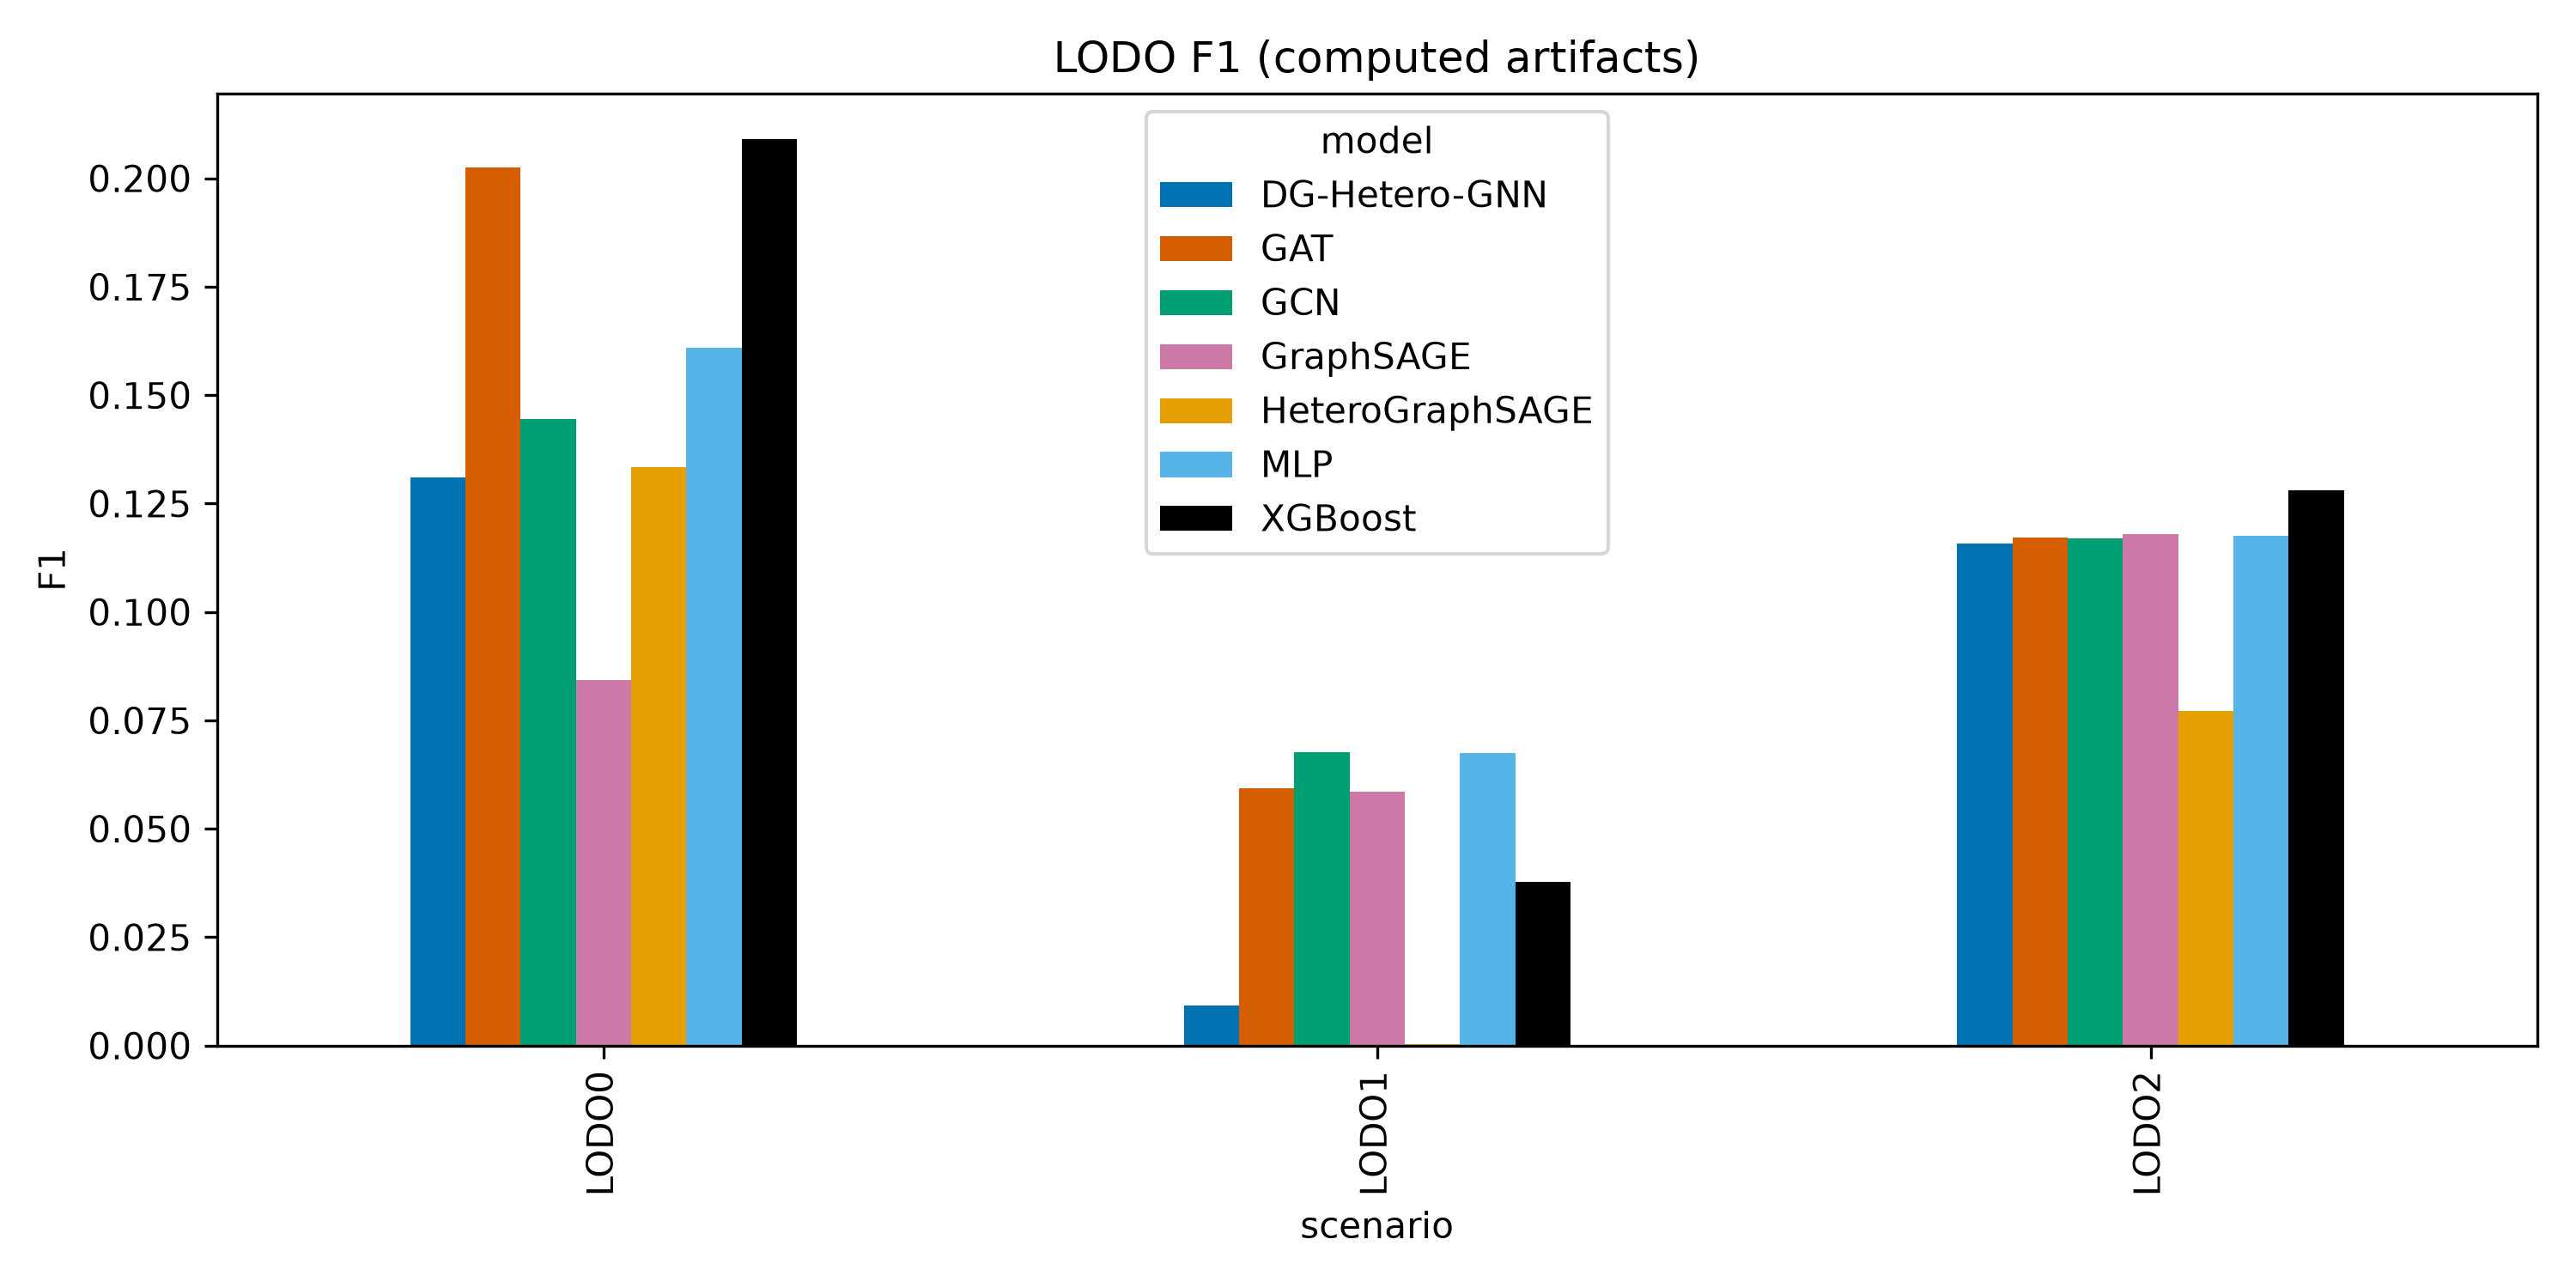

### figure3d_ablation.png

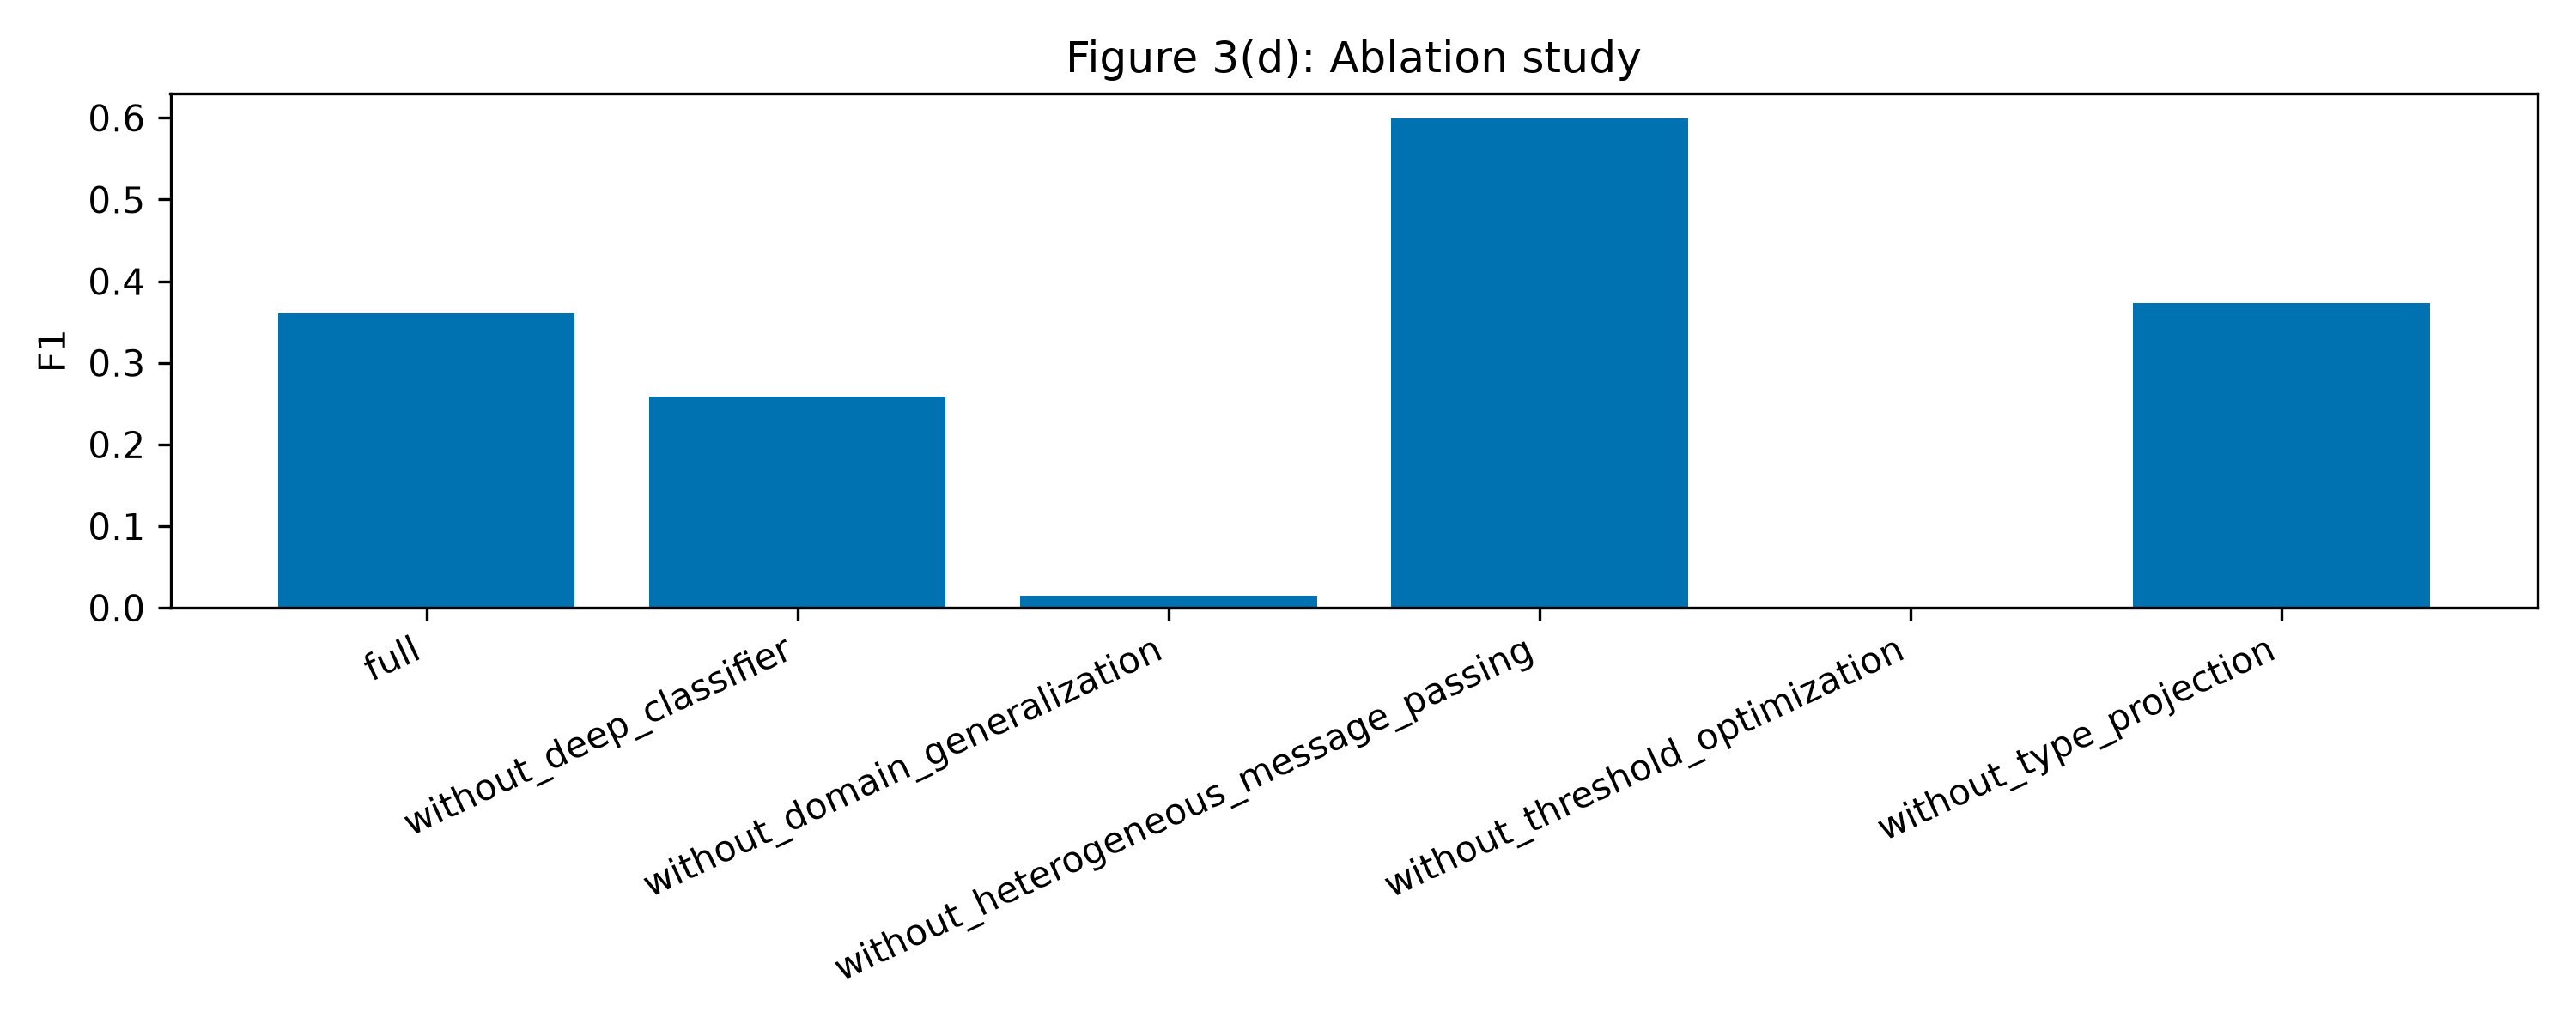

In [10]:
for filename in ['figure3a_lodo_roc_auc.png','figure3b_lodo_pr_auc.png','figure3c_lodo_f1.png','figure3d_ablation.png']:
    display(Markdown('### '+filename))
    display(Image(filename=str(COMPLETED_RUN/'figures'/filename), width=1000))

## 11. Generate interpretations directly from numerical evidence

To avoid subjective or fabricated commentary, this cell reads `all_results.csv` and calculates its sentences. For each evaluation scenario, it finds the model with the highest mean F1. It then calculates the adaptive-versus-non-adaptive F1 difference and sorts ablations by F1.

This is descriptive, not proof of statistical significance. Large standard deviations indicate seed sensitivity, and a high score should still be checked alongside precision, recall, confusion counts, and calibration.

In [11]:
results = pd.read_csv(COMPLETED_RUN/'tables'/'all_results.csv')
for scenario in ['LODO0','LODO1','LODO2','OOD']:
    block=results[results.scenario==scenario]
    best=block.loc[block['F1_mean'].idxmax()]
    print(f'{scenario}: highest mean F1 = {best["model"]} ({best["F1_mean"]:.4f}); evaluated models = {len(block)}.')
dg=results[(results.scenario=='OOD') & (results.model=='DG-Hetero-GNN')].iloc[0]
adaptive=results[(results.scenario=='ADAPTIVE_OOD') & (results.model=='DG-Hetero-GNN')].iloc[0]
print(f'Adaptive OOD F1 change versus non-adaptive DG: {adaptive.F1_mean-dg.F1_mean:+.4f}.')
abl=results[results.scenario.str.startswith('ABLATION_')].sort_values('F1_mean',ascending=False)
display(abl[['scenario','F1_mean','F1_std','ROC-AUC_mean','PR-AUC_mean']])

LODO0: highest mean F1 = XGBoost (0.2091); evaluated models = 7.
LODO1: highest mean F1 = GCN (0.0676); evaluated models = 7.
LODO2: highest mean F1 = XGBoost (0.1281); evaluated models = 7.
OOD: highest mean F1 = GAT (0.7143); evaluated models = 7.
Adaptive OOD F1 change versus non-adaptive DG: -0.0478.


,scenario,F1_mean,F1_std,ROC-AUC_mean,PR-AUC_mean
3,ABLATION_without_heterogeneous_message_passing,0.599771,0.233293,0.5516,0.641519
5,ABLATION_without_type_projection,0.373108,0.283432,0.4984,0.597325
0,ABLATION_full,0.360714,0.319518,0.3068,0.457350
1,ABLATION_without_deep_classifier,0.258277,0.266653,0.4732,0.575167
2,ABLATION_without_domain_generalization,0.015385,0.030769,0.4036,0.539876
4,ABLATION_without_threshold_optimization,0.000000,0.000000,0.4244,0.532718


## 12. Rebuild every graph and table without retraining

Training and visualization are deliberately separated. The model run saves labels, probabilities, curve coordinates, thresholds, metrics, and aggregate JSON. `render_outputs` reads those artifacts to reproduce the CSV tables and PNG figures.

Leave the switch `False` during ordinary review. Set it to `True` to prove that the displayed graphics can be regenerated from numerical evidence without spending GPU time or changing model predictions. Portable paths are reconstructed from prediction filenames, so this also works after moving or extracting the package.

In [12]:
RENDER_FROM_SAVED_ARTIFACTS = False
if RENDER_FROM_SAVED_ARTIFACTS:
    aggregates=[]
    for path in sorted((COMPLETED_RUN/'results').glob('*.json')):
        if '_seed' not in path.stem:
            item=json.loads(path.read_text(encoding='utf-8'))
            item['prediction_artifacts']=[str(COMPLETED_RUN/'predictions'/Path(saved).name) for saved in item['prediction_artifacts']]
            aggregates.append(item)
    assert len(aggregates)==35
    render_outputs(COMPLETED_RUN, aggregates)
    print('Regenerated all tables and figures from saved artifacts.')
else:
    print('Set RENDER_FROM_SAVED_ARTIFACTS=True to rerender; no model training is required.')

Set RENDER_FROM_SAVED_ARTIFACTS=True to rerender; no model training is required.


## 13. Reviewer handoff and file map

- `DG_Hetero_GNN_Review.ipynb`: this guided review document.
- `paper_reproduction_core.py`: authoritative implementation used for training, evaluation, checkpointing, and rendering.
- `reproduction_tests.py`: executable safety and correctness checks.
- `run_review_once.py`: unattended one-command entry point.
- `requirements-reproduction.txt`: pinned Python dependencies.
- `paper.pdf`: normative research paper.
- `recovery-source/Datasets`: four hash-verified processed graph archives.
- `artifacts_runs`: manifests, predictions, checkpoints, tables, and figures.

For a quick wiring check, run `python -u run_review_once.py`. For a complete fresh experiment, run `python -u run_review_once.py --full --run-id reviewer-full-run`. The latter is long-running and requires suitable memory/GPU resources.

Scientific disagreements with the paper must be documented as discrepancies. Reviewers should never change computed artifacts to make the numbers resemble the paper.